In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

In [2]:
folder_path = "wind_data"

df_list = []
csv_files = [f for f in os.listdir(folder_path) if f.endswith("wind_vane.csv")]
for file in csv_files:
    tempDf = pd.read_csv(folder_path + "/" + file, header = None)
    df_list.append(tempDf)
   
combined_df = pd.concat(df_list, ignore_index=True)

display(combined_df)

,0,1,2,3
0,2025-10-19 14:50:00,2470,568,217.089844
1,2025-10-19 14:51:00,2397,567,210.673828
2,2025-10-19 14:52:00,2365,585,207.861328
3,2025-10-19 14:53:00,2257,563,198.369141
4,2025-10-19 14:54:00,2258,540,198.457031
...,...,...,...,...
5914,2025-10-18 17:10:05,1265,305,111.181641
5915,2025-10-18 17:10:07,1307,342,114.873047
5916,2025-10-18 17:10:09,1192,171,104.765625
5917,2025-10-18 17:10:11,1284,140,112.851562


In [3]:
df = pd.DataFrame()
df["timestamp"] = pd.to_datetime(combined_df[0])
df["wind direction"] = combined_df[3]
df = df.sort_values(by="timestamp")
df.reset_index(drop=True, inplace=True)

north = df.iloc[0]["wind direction"]
df["wind direction calibrated"] = df["wind direction"] - north

print(df)

               timestamp  wind direction  wind direction calibrated
0    2025-10-18 15:52:31      204.433594                   0.000000
1    2025-10-18 15:52:33      204.433594                   0.000000
2    2025-10-18 15:52:35      204.433594                   0.000000
3    2025-10-18 15:52:37      204.433594                   0.000000
4    2025-10-18 15:52:39      204.433594                   0.000000
...                  ...             ...                        ...
5914 2025-10-21 18:02:20      100.195312                -104.238281
5915 2025-10-21 18:03:20       99.843750                -104.589844
5916 2025-10-21 18:04:09      339.873047                 135.439453
5917 2025-10-21 18:05:09      339.873047                 135.439453
5918 2025-10-21 18:06:09      339.873047                 135.439453

[5919 rows x 3 columns]


In [4]:
df["wind direction calibrated"].to_csv("wind_speed.txt", index=False, header=False, lineterminator="", sep=",")



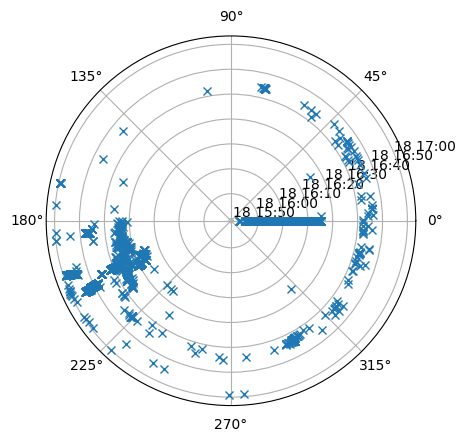

In [5]:

low = pd.Timestamp("2025-10-18-12")
high = pd.Timestamp("2025-10-18-17")
cutDf = df[(df["timestamp"] >= low) & (df["timestamp"] <= high)]

# plt.plot(cutDf["timestamp"], cutDf["wind direction calibrated"])

angles = cutDf["wind direction calibrated"].values  # your data
angles_wrapped = angles % 360
angles_unwrapped = np.unwrap(np.deg2rad(angles))  # unwrap in radians
angles_smooth = np.rad2deg(angles_unwrapped) % 360


fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(angles_unwrapped, cutDf["timestamp"], "x")

plt.show()

In [ ]:
#Ask what the 2nd column means, if it includes wind direction can filter out very flimsy wind changes
#Reorient north from right side to up
#Add line from point to center

In [6]:
x = np.array(df["wind direction calibrated"].values)
y = np.array(df["wind direction"].values)

Animation saved to wind_vane.mp4


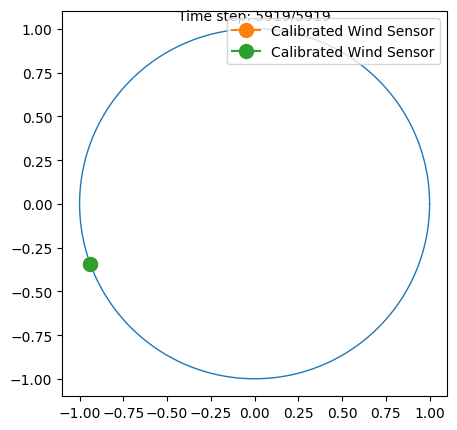

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def animate_wind_vanes_deg(x, y, interval=200, save_path=None):
    """
    Create an animation showing two wind vane readings (in degrees) on a unit circle.

    Parameters:
    - x_deg: array-like, angles in **degrees** from vane 1
    - y_deg: array-like, angles in **degrees** from vane 2
    - interval: int, milliseconds between frames
    - save_path: str or None, if provided, save animation to this mp4 file
    @Author: Victor
    """

    # Setup figure and unit circle
    fig, ax = plt.subplots(figsize=(5,5))
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.plot(np.cos(np.linspace(0,2*np.pi,200)),
            np.sin(np.linspace(0,2*np.pi,200)),
            lw=1)

    # Initialize points
    point1, = ax.plot([], [], marker='o', markersize=10, label='Calibrated Wind Sensor')
    point2, = ax.plot([], [], marker='o', markersize=10, label='Calibrated Wind Sensor')
    time_text = ax.text(0, 1.05, '', ha='center')
    ax.legend(loc='upper right')

    def init():
        point1.set_data([], [])
        point2.set_data([], [])
        time_text.set_text('')
        return point1, point2, time_text

    def update(i):
        x1, y1 = np.cos(x[i]), np.sin(x[i])
        x2, y2 = np.cos(y[i]), np.sin(y[i])
        # wrap in lists so set_data sees a sequence
        point1.set_data([x1], [y1])
        point2.set_data([x2], [y2])
        time_text.set_text(f'Time step: {i+1}/{len(x)}')
        return point1, point2, time_text

    anim = FuncAnimation(fig, update, frames=len(x),
                         init_func=init, blit=True,
                         interval=interval)

    if save_path:
        anim.save(save_path,writer='ffmpeg', fps=10)
        print(f"Animation saved to {save_path}")

    return anim



anim = animate_wind_vanes_deg(x, x, interval=10, save_path="wind_vane.mp4")
